**What is churn?**
Churn = a customer stops using the company's service (cancels their subscription). Businesses care a LOT about this because it's cheaper to keep an existing customer than to find a new one. So companies want to predict who is about to leave, so they can offer discounts/support before it happens.

**Our job:** Given a customer's data , predict: will they churn (Yes) or not (No)?

This is a **binary classification** problem.

# Getting the data and understanding the problem

In [44]:
import pandas as pd
import numpy as np

# Downloading the dataset directly
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
# Basic info
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

In [46]:
# Checking target variable
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


# Exploratory Data Analysis (EDA)

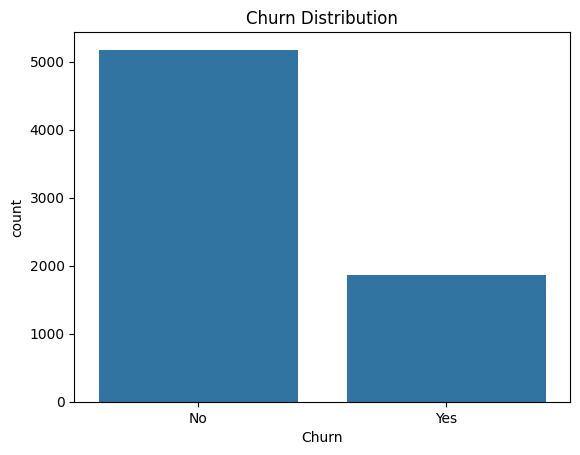

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Overall churn rate
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)




It tells what % of customers churn overall. Usually around 26-27% in this dataset

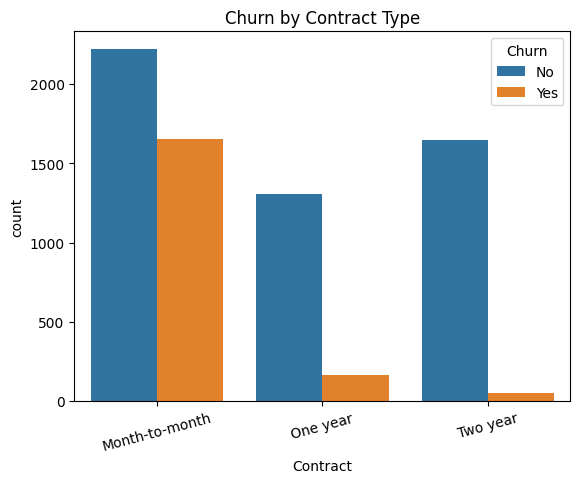

In [48]:
# Does contract type affect churn?
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

It shows that month-to-month customers churn way more than customers on 1-year or 2-year contracts (that is long contracts lock people in)

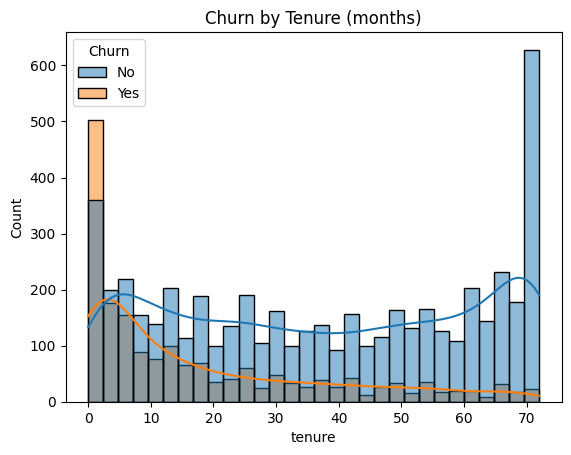

In [49]:
# Does tenure (how long they've been a customer) affect churn?
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Churn by Tenure (months)")
plt.show()

This shows that new customers (low tenure) churn a lot more than long-time customers.

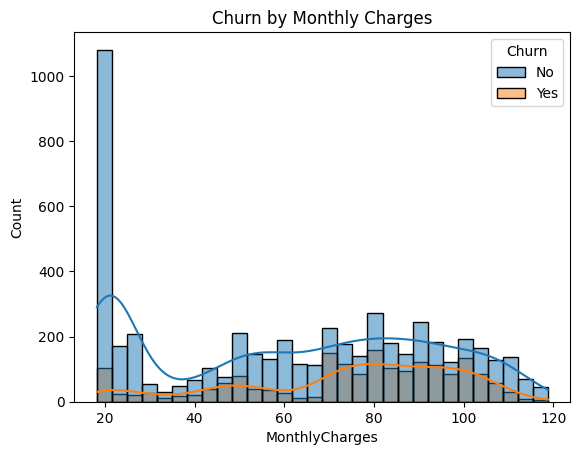

In [50]:
# Monthly charges vs churn
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.title("Churn by Monthly Charges")
plt.show()

This shows that customers paying higher monthly charges tend to churn more

In summary churn is driven mainly by contract type, tenure, and monthly charges — customers who are new, on month-to-month plans, and paying more are the highest risk group.

# Data Cleaning & Preprocessing

In [51]:
# Droping customerID because it is not useful for prediction
df = df.drop('customerID', axis=1)



In [52]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [53]:
# TotalCharges is stored as text but should be a number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [54]:
# Checking how many rows became missing (NaN) after conversion
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())


Missing values in TotalCharges: 11


In [55]:
# These are usually customers with 0 tenure (new), so we fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [56]:
# Checking again how many rows are missing
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 0


In [57]:
# Converting target column Churn (Yes/No) to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,0


In [58]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('Churn')  # target isn't a feature

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [60]:
# One-hot encode categorical columns
# This turns "Contract: Month-to-month/One year/Two year" into 3 separate 0/1 columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (7043, 31)


In [62]:
# Split features (X) and target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Why stratify=y: Since churn is imbalanced (26% vs 74%),
# this makes sure both train and test sets keep the same ratio. Otherwise you could randomly end up with almost no churners in your test set

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 30)
Test shape: (1409, 30)


In [63]:
# Scale numerical features
# ANNs train better and faster when features are on a similar scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handling Class Imbalance

 Since ~74% of customers don't churn. If our model just predicted "No" for everyone, it'd be 74% "accurate" but completely useless — it would never catch a single churner. We need the model to pay extra attention to the minority class (churners).

In [64]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


Since churn was imbalanced (~26%), I used class weighting during training so the model wouldn't just predict the majority class and get a falsely high accuracy

# Building & Training the ANN

Why an ANN here:

We have structured/tabular data (rows of customer features), and we're predicting a binary outcome. An ANN with a few hidden layers can learn non-linear combinations of features better than a simple linear model.

In [65]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build the model
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),   # input layer = number of features
    layers.Dense(32, activation='relu'),                # hidden layer 1
    layers.Dropout(0.3),                                 # prevents overfitting
    layers.Dense(16, activation='relu'),                # hidden layer 2
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')                # output layer (probability between 0-1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Dropout(0.3):
randomly "turns off" 30% of neurons during each training step. This prevents the model from memorizing the training data (overfitting) and forces it to learn general patterns

In [66]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # standard loss for binary classification
    metrics=['accuracy']
)

Adam optimizer: an algorithm that adjusts the model's internal weights to reduce error

Binary crossentropy: the loss function

In [67]:
# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,       # holds back 20% of training data to check for overfitting during training
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5895 - loss: 0.6293 - val_accuracy: 0.7036 - val_loss: 0.5559
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7273 - loss: 0.5411 - val_accuracy: 0.7338 - val_loss: 0.5270
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7426 - loss: 0.5233 - val_accuracy: 0.7285 - val_loss: 0.5146
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7451 - loss: 0.5147 - val_accuracy: 0.7311 - val_loss: 0.5151
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7484 - loss: 0.5089 - val_accuracy: 0.7418 - val_loss: 0.4965
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7497 - loss: 0.5083 - val_accuracy: 0.7258 - val_loss: 0.5152
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7495 - loss: 0.4983 - val_accuracy: 0.7374 - val_loss: 0.4985
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7528 - loss: 0.5055 - val_accuracy: 0.

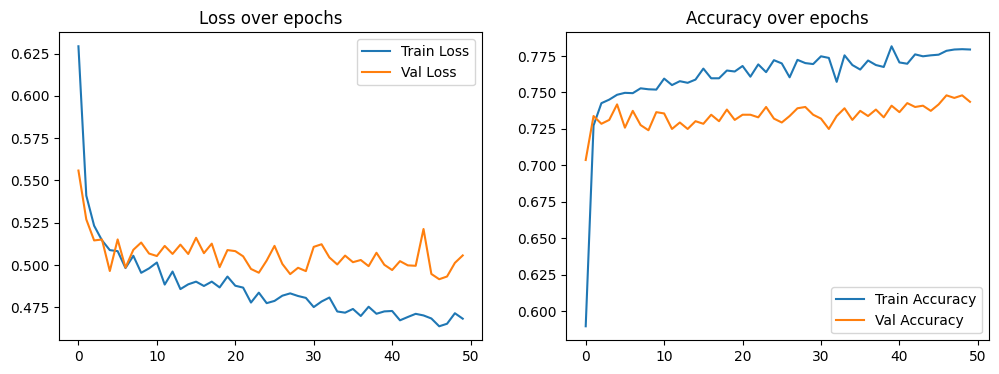

In [68]:
# Plot training history
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss over epochs')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy over epochs')

plt.show()

If validation loss starts going UP while training loss keeps going DOWN, that's overfitting — the model is memorizing instead of learning. If both lines flatten out together nicely, that's a well-trained model

#  Evaluation

We need better metrics because accuracy alone can be misleading:

We already discussed — with 74% "No churn", a lazy model could get 74% accuracy by never predicting churn.

In [69]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

# Predict probabilities
y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.76      1409



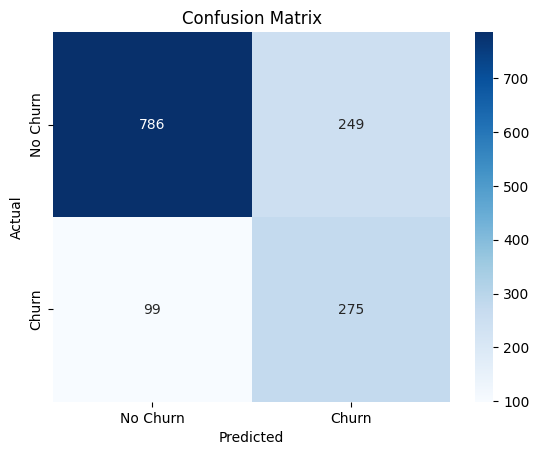

In [70]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Top-left = correctly predicted "No Churn"

Bottom-right = correctly predicted "Churn" (this is what we care about most)

Bottom-left = actual churners we MISSED (false negatives — the costly mistake)

Top-right = false alarms (false positives)

ROC-AUC Score: 0.834


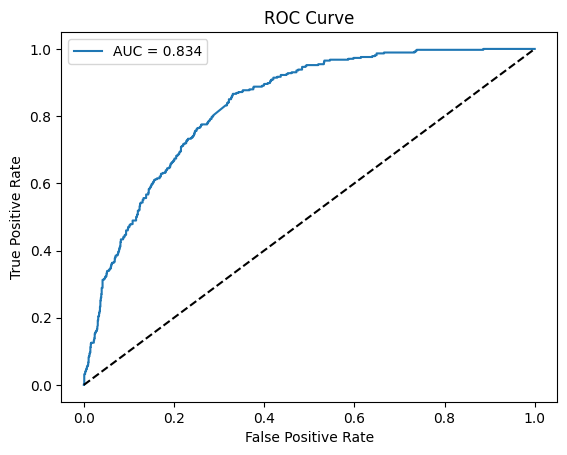

In [71]:
# ROC-AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.3f}")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

ROC-AUC means: A single score (0.5 to 1.0) measuring how well the model separates churners from non-churners, regardless of threshold.

 random guessing=0.5, perfect = 1.

In [72]:
# Which features matter most?
importance = df_encoded.corr()['Churn'].sort_values(ascending=False)
print(importance.head(10))
print(importance.tail(10))

Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService_Yes                  0.011942
Name: Churn, dtype: float64
TotalCharges                           -0.198324
InternetService_No                     -0.227890
StreamingTV_No internet service        -0.227890
OnlineSecurity_No internet service     -0.227890
OnlineBackup_No internet service       -0.227890
DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
TechSupport_No internet service        -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
Name: Churn, dtype: float64


This shows :

Positive correlation = increases churn risk (e.g. month-to-month contract, high monthly charges, low tenure).

Negative correlation = reduces churn risk (e.g. long tenure, 2-year contracts, having tech support).

In [73]:
# Saveing the model and the scaler
model.save('churn_ann_model.h5')

import joblib
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved!")

Model and scaler saved!


Summary :

"I built an ANN to predict customer churn on the Telco dataset. After EDA, I found churn is driven mainly by contract type, tenure, and monthly charges. I one-hot encoded categorical features, scaled numerical ones, and handled the ~26% class imbalance using class weights. The ANN has two hidden layers with dropout to prevent overfitting. I evaluated using precision/recall/F1 and ROC-AUC rather than just accuracy, since accuracy is misleading on imbalanced data. My model achieved an AUC of about 0.834 — meaning it separates churners from non-churners quite well."